In [8]:
!pip install openai pandas matplotlib

In [9]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

print("ключ підключений")

Ключ підключено.


                                              review
0  The food was very tasty and fresh, but the ser...
1  I liked the atmosphere. The restaurant is cozy...
2  The waiter was rude and did not explain the menu.
3    The pizza was delicious and the price was fair.
4   The delivery was late and the food arrived cold.
кількість відгуків: 50
колонка review є
аналіз відгука 1
аналіз відгука 2
аналіз відгука 3
аналіз відгука 4
аналіз відгука 5
аналіз відгука 6
аналіз відгука 7
аналіз відгука 8
аналіз відгука 9
аналіз відгука 10
аналіз відгука 11
аналіз відгука 12
аналіз відгука 13
аналіз відгука 14
аналіз відгука 15
аналіз відгука 16
аналіз відгука 17
аналіз відгука 18
аналіз відгука 19
аналіз відгука 20
аналіз відгука 21
аналіз відгука 22
аналіз відгука 23
аналіз відгука 24
аналіз відгука 25
аналіз відгука 26
аналіз відгука 27
аналіз відгука 28
аналіз відгука 29
аналіз відгука 30
аналіз відгука 31
аналіз відгука 32
аналіз відгука 33
аналіз відгука 34
аналіз відгука 35
аналіз відгука 36
ана

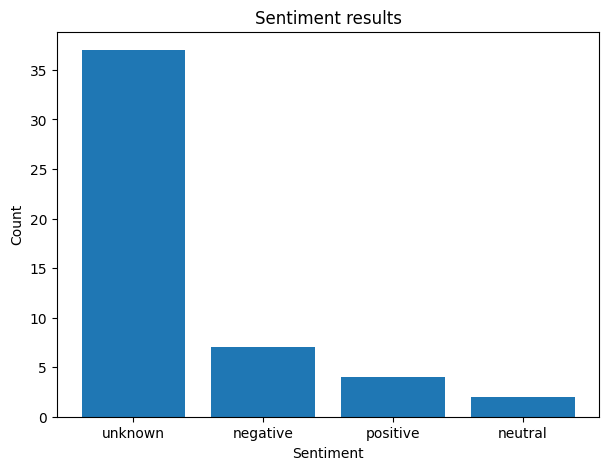

найчастіші теми:
service               3
atmosphere            1
cleanliness           1
menu explanation      1
portion size          1
pricing               1
vegetarian options    1
menu variety          1
professionalism       1
family                1
Name: count, dtype: int64


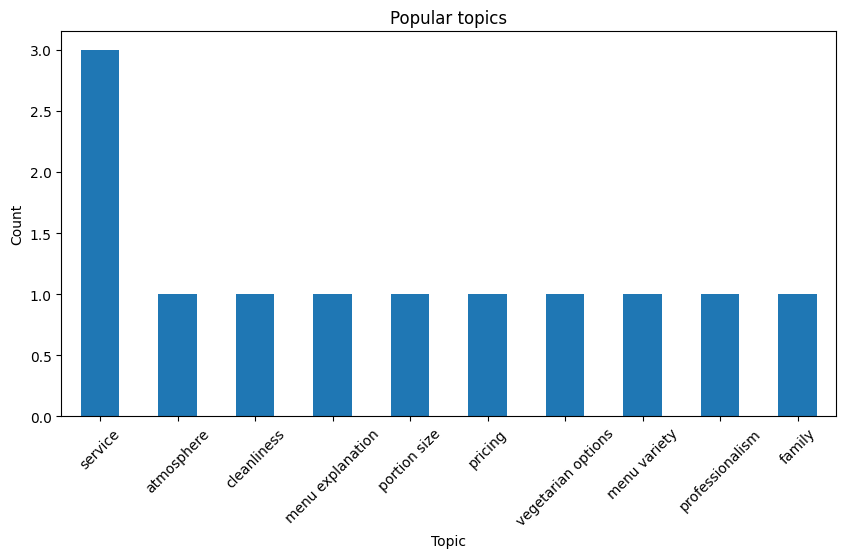

найчастіші пропозиції:
Improve waiter training                   1
Provide clearer menu descriptions         1
increase portion sizes                    1
adjust pricing                            1
add more vegetarian dishes                1
expand the menu options                   1
double-check orders before fulfillment    1
improve wait times for corrections        1
simplify the app interface                1
provide a tutorial for new users          1
Name: count, dtype: int64


In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI


client = OpenAI()

# --------- читаю csv файл ---------
df = pd.read_csv("reviews.csv")

print(df.head())
print("кількість відгуків:", len(df))

# ---------перевірка щоб була колонка review ---------
if "review" not in df.columns:
    print("немає колонки review")
else:
    print("колонка review є")


# ---------функція для аналізу одного відгуку ---------
def analyze_review(text):
    prompt = f"""
Analyze this customer review:

{text}

Return only JSON:
{{
  "sentiment": "positive/negative/neutral",
  "topics": ["topic1", "topic2"],
  "suggestions": ["suggestion1", "suggestion2"]
}}
"""

    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt
    )

    answer = response.output_text

    # -------- пробую перевести відповідь в json -------
    try:
        result = json.loads(answer)
    except:
        result = {
            "sentiment": "unknown",
            "topics": [],
            "suggestions": []
        }

    return result


# ---------- тут будуть результати --------
sentiments = []
topics = []
suggestions = []

# -------- проходимось по всіх відгуках -------
for i in range(len(df)):
    print("аналіз відгука", i + 1)

    text = str(df.loc[i, "review"])
    result = analyze_review(text)

    sentiments.append(result["sentiment"])
    topics.append(", ".join(result["topics"]))
    suggestions.append(", ".join(result["suggestions"]))


# --------- додаю нові колонки ------------
df["sentiment"] = sentiments
df["topics"] = topics
df["suggestions"] = suggestions

# ----------- зберігаю новий файл --------
df.to_csv("reviews_analyzed.csv", index=False)

print("готово")
print(df.head())


# --------- графік настроїв ---------
sentiment_count = df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title("Sentiment results")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.savefig("sentiment_plot.png")
plt.show()


# --------- рахуємо теми ---------
all_topics = []

for item in df["topics"]:
    parts = str(item).split(",")

    for p in parts:
        p = p.strip()

        if p != "":
            all_topics.append(p)

topic_count = pd.Series(all_topics).value_counts()

print("найчастіші теми:")
print(topic_count.head(10))


# --------- графік тем ---------
plt.figure(figsize=(10, 5))
topic_count.head(10).plot(kind="bar")
plt.title("Popular topics")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("topics_plot.png", bbox_inches="tight")
plt.show()


# --------- рахуємо пропозиції ---------
all_suggestions = []

for item in df["suggestions"]:
    parts = str(item).split(",")

    for p in parts:
        p = p.strip()

        if p != "":
            all_suggestions.append(p)

suggestion_count = pd.Series(all_suggestions).value_counts()

print("найчастіші пропозиції:")
print(suggestion_count.head(10))


# --------- роблю readme файл ---------
with open("README.txt", "w", encoding="utf-8") as f:
    f.write("Практичне заняття 10. OpenAI API\n\n")

    f.write("У цій роботі я зробив аналіз відгуків клієнтів через OpenAI API.\n")
    f.write("Спочатку я завантажив файл reviews.csv, де були відгуки про ресторан.\n")
    f.write("Потім для кожного відгуку модель визначила настрій, теми і пропозиції для покращення.\n\n")

    f.write("Кількість відгуків: " + str(len(df)) + "\n\n")

    f.write("Розподіл настроїв:\n")
    f.write(str(sentiment_count) + "\n\n")

    f.write("Найчастіші теми:\n")
    f.write(str(topic_count.head(10)) + "\n\n")

    f.write("Найчастіші пропозиції:\n")
    f.write(str(suggestion_count.head(10)) + "\n\n")

    f.write("Висновок:\n")
    f.write("За результатами видно, що клієнти найчастіше звертають увагу на якість їжі, сервіс, ціни, доставку та атмосферу. ")
    f.write("Якщо відгуки негативні, то найчастіше проблема пов'язана з повільним обслуговуванням, холодною їжею або високими цінами. ")
    f.write("Для покращення ресторану можна зробити швидше обслуговування, додати більше страв у меню, покращити доставку та уважніше перевіряти замовлення.\n")
